# This notebook loads the data and classifies cities according to their potential for the implementation of blue-green infrastructure.
##### Author: Omid Emamjomehzadeh (https://www.omidemam.com/)
##### Supervisor: Dr. Omar Wani (https://engineering.nyu.edu/faculty/omar-wani)
##### Hydrologic Systems Group @NYU (https://www.omarwani.com/)

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from skfuzzy.cluster import cmeans
import datetime
from mpl_toolkits.mplot3d import Axes3D, proj3d
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
from adjustText import adjust_text
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FormatStrFormatter, MultipleLocator, FixedLocator
from pathlib import Path
import os

In [ ]:
current_folder = Path.cwd().parent.parent
os.chdir(current_folder)
print("Current folder:", current_folder)
file_path = Path(current_folder) / "results" / "GIPI_Results.xls"

Current folder: c:\Omid\Repos\bgipotential


In [6]:
# Read the cities coordinates
BGIPI = pd.read_excel(file_path, header=0)
BGIPI.columns

Index(['OBJECTID_1', 'City', 'Population__US_Census', 'Area_of_City__m2_',
       'Precip___inches_', 'Normalized_P', 'Abs_P_Norm', 'F__CSO_Outfalls',
       'CSO_Cumul__Normal', 'Abs_CSO_Norm', 'P__Lot_Area__m2_',
       'P__Lot_Area_Cumul__Norm', 'Abs_PLA_Norm',
       'P__Lot_Area_per_unit_area_of_the_city', 'PLA_perarea_Abs_norm',
       'August_Night_Low', 'August_Lows_Normal', 'Abs_AugT_Norm',
       'HydroRiskAvg', 'HeatRiskAvg', 'AQAvg', 'ImpervAvg', 'HeatGeoAvg',
       'Tbl_GIPI'],
      dtype='str')

In [7]:
cols = ['City', 'HydroRiskAvg', 'HeatRiskAvg', 'AQAvg']
df = BGIPI[cols].copy()

df['HydroRisk_rank'] = df['HydroRiskAvg'].rank(ascending=False, method='min').astype(int)
df['HeatRisk_rank'] = df['HeatRiskAvg'].rank(ascending=False, method='min').astype(int)
df['AQ_rank'] = df['AQAvg'].rank(ascending=False, method='min').astype(int)


df[['City','HydroRisk_rank','HeatRisk_rank','AQ_rank']]

,City,HydroRisk_rank,HeatRisk_rank,AQ_rank
0,NYC,3,1,10
1,FtWorth,7,2,7
2,Dallas,6,3,3
3,Phoenix,16,4,5
4,Houston,4,5,1
5,SanAntonio,9,6,14
6,Philadelphia,2,7,13
7,Austin,10,8,18
8,Jacksonville,18,9,19
9,Chicago,1,10,9


In [ ]:
# Features for clustering
X = df[['HydroRiskAvg', 'HeatRiskAvg', 'AQAvg']].values

# Standardize before KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Search for best k
k_range = range(2, 20)   
scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

best_k = k_range[np.argmax(scores)]
print("Best number of clusters:", best_k)
print("Best silhouette score:", max(scores))

# Final model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# rename clusters to Class 1, Class 2, ...
df['Class'] = 'Class ' + (df['Cluster'] + 1).astype(str)

c:\Users\omide\anaconda3\envs\bgipotential\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Best number of clusters: 3
Best silhouette score: 0.3465758341449029


In [9]:
print(df[['City', 'HydroRiskAvg', 'HeatRiskAvg', 'AQAvg', 'Cluster', 'Class']].sort_values('Cluster'))

            City  HydroRiskAvg  HeatRiskAvg     AQAvg  Cluster    Class
7         Austin      0.337667     0.410946  0.581975        0  Class 1
5     SanAntonio      0.350029     0.448544  0.629415        0  Class 1
10     Charlotte      0.325220     0.388194  0.624730        0  Class 1
8   Jacksonville      0.206690     0.399350  0.335997        0  Class 1
12      Columbus      0.415051     0.331028  0.320335        0  Class 1
4        Houston      0.427819     0.452881  0.939097        1  Class 2
0            NYC      0.452366     0.595656  0.757569        1  Class 2
1        FtWorth      0.378274     0.500655  0.841030        1  Class 2
15  Indianapolis      0.372579     0.323023  0.760518        1  Class 2
6   Philadelphia      0.452635     0.420383  0.724252        1  Class 2
2         Dallas      0.402334     0.464912  0.904032        1  Class 2
9        Chicago      0.478363     0.391615  0.757895        1  Class 2
3        Phoenix      0.215013     0.455387  0.850364        2  

In [10]:
# Cluster centers in original scale
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(
    centers_original,
    columns=['HydroRiskAvg', 'HeatRiskAvg', 'AQAvg']
)
centers_df.index = ['Class ' + str(i+1) for i in range(best_k)]

print("\nCluster centers:")
print(centers_df)


Cluster centers:
         HydroRiskAvg  HeatRiskAvg     AQAvg
Class 1      0.326931     0.395613  0.498490
Class 2      0.423481     0.449875  0.812056
Class 3      0.231430     0.298861  0.776364


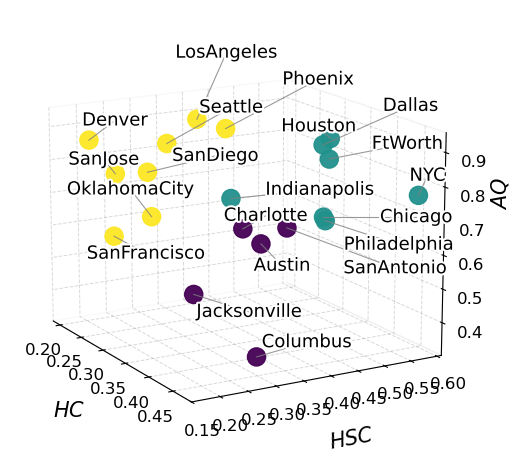

In [12]:
class_col = 'ClassNum' if 'ClassNum' in df.columns else 'Cluster'
class_vals = df[class_col].values
classes = np.sort(np.unique(class_vals))

bg = 'white'

x = df['HydroRiskAvg'].values
y = df['HeatRiskAvg'].values
z = df['AQAvg'].values
names = df['City'].values

pad_x = 0.03 * (x.max() - x.min())
pad_y = 0.03 * (y.max() - y.min())
pad_z = 0.03 * (z.max() - z.min())

fig = plt.figure(figsize=(8*0.9, 6*0.9))
fig.patch.set_facecolor(bg)

ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor(bg)

ax.xaxis.pane.set_facecolor((1, 1, 1, 1))
ax.yaxis.pane.set_facecolor((1, 1, 1, 1))
ax.zaxis.pane.set_facecolor((1, 1, 1, 1))

scatter = ax.scatter(
    x, y, z,
    c=class_vals,
    s=170,
    alpha=0.95,
    depthshade=True
)

ax.set_xlabel(f'$HC$', fontsize=15, labelpad=12)
ax.set_ylabel(f'$HSC$', fontsize=15, labelpad=12)
ax.set_zlabel('')
fig.text(0.85, 0.56, f'$AQ$', rotation=90, va='center', ha='center', fontsize=15)

#ax.set_title('City Clustering', fontsize=18, pad=2)

ax.tick_params(axis='both', which='major', labelsize=12)
ax.zaxis.set_tick_params(labelsize=12)

ax.set_xlim(x.min() - pad_x, x.max() + pad_x)
ax.set_ylim(y.min() - pad_y, y.max() + pad_y)
ax.set_zlim(z.min() - pad_z, z.max() + pad_z)

ax.set_box_aspect((1.05, 1.0, 0.8))
ax.view_init(elev=15, azim=-30)
ax.grid(True)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['linestyle'] = '--'
    axis._axinfo["grid"]['linewidth'] = 0.7
    axis._axinfo["grid"]['color'] = (0.5, 0.5, 0.5, 0.3)
# ---------- project 3D points to 2D ----------
fig.canvas.draw()

x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
xy_pixels = ax.transData.transform(np.column_stack([x2, y2]))
xy_axes = ax.transAxes.inverted().transform(xy_pixels)

# ---------- create movable 2D labels ----------
texts = []
for (xa, ya), label in zip(xy_axes, names):
    txt = ax.text2D(
        xa, ya, label,
        transform=ax.transAxes,
        fontsize=13,
        ha='left',
        va='bottom',
        color='black',
        path_effects=[pe.withStroke(linewidth=3, foreground='white')],
        zorder=10
    )
    texts.append(txt)

# ---------- move labels ----------
adjust_text(
    texts,
    ax=ax,
    expand=(1.15, 1.20),
    force_text=(0.6, 0.9),
    force_static=(0.4, 0.6),
    only_move={'text': 'xy'}
)

# redraw so final text positions are known
fig.canvas.draw()

# ---------- draw manual connector lines ----------
for (xa, ya), txt in zip(xy_axes, texts):
    # current text position in axes-fraction coordinates
    xt, yt = txt.get_position()

    # draw a 2D line in axes coordinates
    line = Line2D(
        [xa, xt], [ya, yt],
        transform=ax.transAxes,
        color='gray',
        linewidth=0.8,
        alpha=0.8,
        zorder=9
    )
    ax.add_line(line)

# ---------- legend ----------
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=classes.min(), vmax=classes.max())

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=cmap(norm(c)),
        markeredgecolor='none',
        markersize=10,
        label=f'Class {int(c)}' if class_col == 'ClassNum' else f'Cluster {int(c)}'
    )
    for c in classes
]

#ax.legend(
#    handles=legend_handles,
#    title='Classes',
#    loc='upper left',
#    bbox_to_anchor=(0.02, 0.98),
#    fontsize=11,
#    title_fontsize=12,
#    frameon=True
#)

plt.subplots_adjust(left=0.03, right=0.94, top=0.90, bottom=0.06)
#plt.savefig('city_clustering_3d.png', dpi=300, bbox_inches='tight')
plt.show()

# Fuzzy C-Means Clustering with 3 Classes

In [13]:
# Fuzzy C-Means with 3 clusters
c = 3
cntr, u, u0, d, jm, p, fpc = cmeans(X_scaled.T, c, 3, error=0.005, maxiter=1000, init=None)

# u is membership matrix (c, n)
df['Fuzzy_Cluster'] = np.argmax(u, axis=0)
df['Membership'] = np.max(u, axis=0)
df['Fuzzy_Class'] = 'Class ' + (df['Fuzzy_Cluster'] + 1).astype(str)

print("Number of clusters:", c)
print("Fuzzy partition coefficient (FPC):", fpc)

Number of clusters: 3
Fuzzy partition coefficient (FPC): 0.44478252260254514


In [14]:
# Cluster centers in original scale
centers_original = scaler.inverse_transform(cntr.T)  # cntr is (c, features)
centers_df = pd.DataFrame(
    centers_original,
    columns=['HydroRiskAvg', 'HeatRiskAvg', 'AQAvg']
)
centers_df.index = ['Class ' + str(i+1) for i in range(c)]

print("\nCluster centers:")
print(centers_df)


Cluster centers:
         HydroRiskAvg  HeatRiskAvg     AQAvg
Class 1      0.403341     0.281641  0.735086
Class 2      0.399505     0.293562  0.749886
Class 3      0.387151     0.391214  0.612169


In [15]:
df['Membership_Class1'] = u[0, :]
df['Membership_Class2'] = u[1, :]
df['Membership_Class3'] = u[2, :]

df[['City', 'HydroRiskAvg', 'HeatRiskAvg', 'AQAvg', 'Fuzzy_Cluster', 'Fuzzy_Class', 'Membership', 'Membership_Class1', 'Membership_Class2', 'Membership_Class3']].sort_values('Fuzzy_Cluster')

,City,HydroRiskAvg,HeatRiskAvg,AQAvg,Fuzzy_Cluster,Fuzzy_Class,Membership,Membership_Class1,Membership_Class2,Membership_Class3
0,NYC,0.452366,0.595656,0.757569,0,Class 1,0.497591,0.497591,0.201101,0.301308
1,FtWorth,0.378274,0.500655,0.841030,0,Class 1,0.680332,0.680332,0.129432,0.190236
2,Dallas,0.402334,0.464912,0.904032,0,Class 1,0.737275,0.737275,0.113467,0.149257
4,Houston,0.427819,0.452881,0.939097,0,Class 1,0.654897,0.654897,0.153048,0.192055
6,Philadelphia,0.452635,0.420383,0.724252,0,Class 1,0.506482,0.506482,0.176633,0.316886
9,Chicago,0.478363,0.391615,0.757895,0,Class 1,0.489031,0.489031,0.200127,0.310842
11,LosAngeles,0.252380,0.367166,0.916868,1,Class 2,0.435721,0.289049,0.435721,0.275231
3,Phoenix,0.215013,0.455387,0.850364,1,Class 2,0.363802,0.315087,0.363802,0.321111
14,OklahomaCity,0.201819,0.323257,0.597112,1,Class 2,0.506083,0.172115,0.506083,0.321802
13,SanDiego,0.191872,0.324397,0.729026,1,Class 2,0.658375,0.135841,0.658375,0.205783


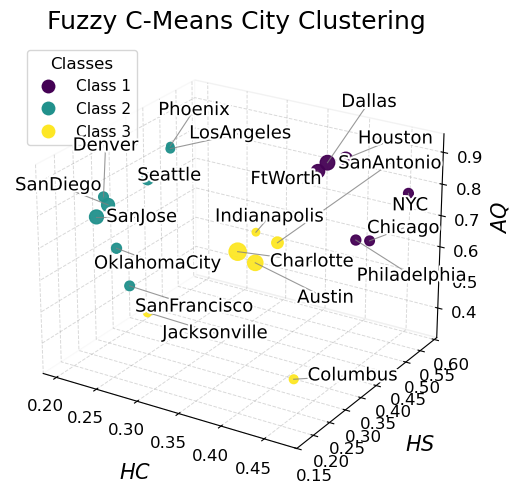

In [16]:
class_col = 'Fuzzy_Cluster'
class_vals = df[class_col].values
classes = np.sort(np.unique(class_vals))

bg = 'white'

x = df['HydroRiskAvg'].values
y = df['HeatRiskAvg'].values
z = df['AQAvg'].values
names = df['City'].values

pad_x = 0.03 * (x.max() - x.min())
pad_y = 0.03 * (y.max() - y.min())
pad_z = 0.03 * (z.max() - z.min())

fig = plt.figure(figsize=(8*0.9, 6*0.9))
fig.patch.set_facecolor(bg)

ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor(bg)

ax.xaxis.pane.set_facecolor((1, 1, 1, 1))
ax.yaxis.pane.set_facecolor((1, 1, 1, 1))
ax.zaxis.pane.set_facecolor((1, 1, 1, 1))

scatter = ax.scatter(
    x, y, z,
    c=class_vals,
    s=df['Membership']**2 * 200,
    alpha=0.95,
    depthshade=True
)

ax.set_xlabel(f'$HC$', fontsize=15, labelpad=12)
ax.set_ylabel(f'$HS$', fontsize=15, labelpad=12)
ax.set_zlabel('')
fig.text(0.85, 0.56, f'$AQ$', rotation=90, va='center', ha='center', fontsize=15)

ax.set_title('Fuzzy C-Means City Clustering', fontsize=18, pad=2)

ax.tick_params(axis='both', which='major', labelsize=12)
ax.zaxis.set_tick_params(labelsize=12)

ax.set_xlim(x.min() - pad_x, x.max() + pad_x)
ax.set_ylim(y.min() - pad_y, y.max() + pad_y)
ax.set_zlim(z.min() - pad_z, z.max() + pad_z)

ax.set_box_aspect((1.05, 1.0, 0.8))
ax.view_init(elev=24, azim=-58)
ax.grid(True)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['linestyle'] = '--'
    axis._axinfo["grid"]['linewidth'] = 0.7
    axis._axinfo["grid"]['color'] = (0.5, 0.5, 0.5, 0.3)

# ---------- project 3D points to 2D ----------
fig.canvas.draw()

x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
xy_pixels = ax.transData.transform(np.column_stack([x2, y2]))
xy_axes = ax.transAxes.inverted().transform(xy_pixels)

# ---------- create movable 2D labels ----------
texts = []
for (xa, ya), label in zip(xy_axes, names):
    txt = ax.text2D(
        xa, ya, label,
        transform=ax.transAxes,
        fontsize=13,
        ha='left',
        va='bottom',
        color='black',
        path_effects=[pe.withStroke(linewidth=3, foreground='white')],
        zorder=10
    )
    texts.append(txt)

# ---------- move labels ----------
adjust_text(
    texts,
    ax=ax,
    expand=(1.15, 1.20),
    force_text=(0.6, 0.9),
    force_static=(0.4, 0.6),
    only_move={'text': 'xy'}
)

# redraw so final text positions are known
fig.canvas.draw()

# ---------- draw manual connector lines ----------
for (xa, ya), txt in zip(xy_axes, texts):
    # current text position in axes-fraction coordinates
    xt, yt = txt.get_position()

    # draw a 2D line in axes coordinates
    line = Line2D(
        [xa, xt], [ya, yt],
        transform=ax.transAxes,
        color='gray',
        linewidth=0.8,
        alpha=0.8,
        zorder=9
    )
    ax.add_line(line)

# ---------- legend ----------
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=classes.min(), vmax=classes.max())

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=cmap(norm(c)),
        markeredgecolor='none',
        markersize=10,
        label=f'Class {int(c)+1}'
    )
    for c in classes
]

ax.legend(
    handles=legend_handles,
    title='Classes',
    loc='upper left',
    bbox_to_anchor=(0.02, 0.98),
    fontsize=11,
    title_fontsize=12,
    frameon=True
)

plt.subplots_adjust(left=0.03, right=0.94, top=0.90, bottom=0.06)
#plt.savefig('city_clustering_fuzzy_3d.png', dpi=300, bbox_inches='tight')
plt.show()

# Optimize Fuzzy C-Means classes

In [17]:
def xie_beni_index(X, cntr, u):
    N = X.shape[0]
    c = cntr.shape[0]
    um = u ** 2
    dist_sq = np.sum((cntr[:, None, :] - X[None, :, :]) ** 2, axis=2)
    numerator = np.sum(um * dist_sq)
    d_min = np.min(np.sum((cntr[:, None, :] - cntr[None, :, :]) ** 2, axis=2) + np.eye(c) * 1e12)
    return numerator / (N * d_min)

results = []
for c_test in range(2, 5):
    for m_test in [1.5, 2.0, 2.5,3]:
        cntr_test, u_test, u0_test, d_test, jm_test, p_test, fpc_test = cmeans(
            X_scaled.T, c_test, m_test, error=0.005, maxiter=1000, init=None
        )
        pc_test = np.sum(u_test ** 2) / u_test.shape[1]
        pe_test = -np.sum(u_test * np.log(u_test + 1e-12)) / u_test.shape[1]
        xb_test = xie_beni_index(X_scaled, cntr_test, u_test)
        results.append({
            'c': c_test,
            'm': m_test,
            'FPC': fpc_test,
            'PC': pc_test,
            'PE': pe_test,
            'Xie-Beni': xb_test
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Xie-Beni', ascending=True)
print('Fuzzy C-Means optimization results:')
print(results_df[['c', 'm', 'FPC', 'Xie-Beni']])

best = results_df.iloc[0]
print(f"\nBest parameters by Xie-Beni: c={best['c']}, m={best['m']}, FPC={best['FPC']:.4f}, Xie-Beni={best['Xie-Beni']:.4f}")

# Re-run with best parameters
c_opt = int(best['c'])
m_opt = float(best['m'])
cntr_opt, u_opt, _, _, _, _, fpc_opt = cmeans(X_scaled.T, c_opt, m_opt, error=0.005, maxiter=1000, init=None)

df['Fuzzy_Cluster_opt'] = np.argmax(u_opt, axis=0)
df['Membership_opt'] = np.max(u_opt, axis=0)
df['Fuzzy_Class_opt'] = 'Class ' + (df['Fuzzy_Cluster_opt'] + 1).astype(str)
for i in range(c_opt):
    df[f'Membership_opt_Class{i+1}'] = u_opt[i, :]

print(f"Selected optimized fuzzy clustering: c={c_opt}, m={m_opt}, FPC={fpc_opt:.4f}")
df[['City', 'Fuzzy_Cluster_opt', 'Fuzzy_Class_opt', 'Membership_opt'] + [f'Membership_opt_Class{i+1}' for i in range(c_opt)]].head(20)

Fuzzy C-Means optimization results:
    c    m       FPC  Xie-Beni
4   3  1.5  0.824251  0.227695
5   3  2.0  0.618823  0.242384
6   3  2.5  0.508127  0.281491
1   2  2.0  0.690087  0.298407
0   2  1.5  0.829642  0.305456
8   4  1.5  0.808151  0.318736
7   3  3.0  0.444738  0.331458
2   2  2.5  0.607200  0.339359
9   4  2.0  0.555988  0.368869
3   2  3.0  0.562743  0.399414
10  4  2.5  0.421785  0.542084
11  4  3.0  0.344308  7.258520

Best parameters by Xie-Beni: c=3.0, m=1.5, FPC=0.8243, Xie-Beni=0.2277
Selected optimized fuzzy clustering: c=3, m=1.5, FPC=0.8243


,City,Fuzzy_Cluster_opt,Fuzzy_Class_opt,Membership_opt,Membership_opt_Class1,Membership_opt_Class2,Membership_opt_Class3
0,NYC,0,Class 1,0.929559,0.929559,0.016889,0.053552
1,FtWorth,0,Class 1,0.991027,0.991027,0.003320,0.005653
2,Dallas,0,Class 1,0.995390,0.995390,0.002225,0.002385
3,Phoenix,1,Class 2,0.626074,0.205334,0.626074,0.168591
4,Houston,0,Class 1,0.990552,0.990552,0.004807,0.004641
5,SanAntonio,2,Class 3,0.813598,0.160047,0.026356,0.813598
6,Philadelphia,0,Class 1,0.964241,0.964241,0.006887,0.028872
7,Austin,2,Class 3,0.993496,0.004013,0.002492,0.993496
8,Jacksonville,2,Class 3,0.863601,0.034653,0.101745,0.863601
9,Chicago,0,Class 1,0.941819,0.941819,0.015923,0.042259


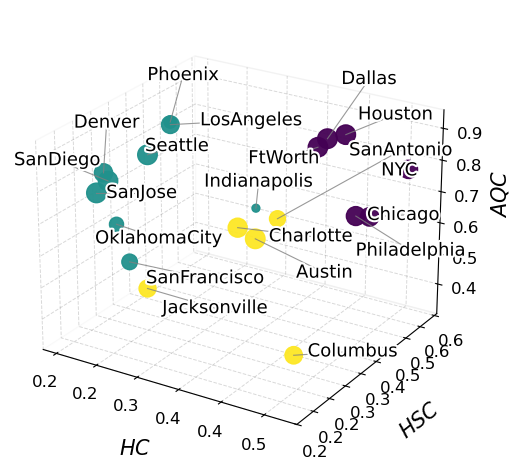

In [19]:
# Plot the optimized fuzzy C-Means classification
class_col = 'Fuzzy_Cluster_opt'
class_vals = df[class_col].values
classes = np.sort(np.unique(class_vals))

bg = 'white'

x = df['HydroRiskAvg'].values
y = df['HeatRiskAvg'].values
z = df['AQAvg'].values
names = df['City'].values

pad_x = 0.03 * (x.max() - x.min())
pad_y = 0.03 * (y.max() - y.min())
pad_z = 0.03 * (z.max() - z.min())

fig = plt.figure(figsize=(8*0.9, 6*0.9))
fig.patch.set_facecolor(bg)

ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor(bg)

ax.xaxis.pane.set_facecolor((1, 1, 1, 1))
ax.yaxis.pane.set_facecolor((1, 1, 1, 1))
ax.zaxis.pane.set_facecolor((1, 1, 1, 1))

scatter = ax.scatter(
    x, y, z,
    c=class_vals,
    s=df['Membership_opt']**2 * 200,
    alpha=0.95,
    depthshade=True
)

ax.set_xlabel(f'$HC$', fontsize=15, labelpad=12)
ax.set_ylabel(f'$HSC$', fontsize=15, labelpad=12)
ax.set_zlabel('')
fig.text(0.85, 0.56, f'$AQC$', rotation=90, va='center', ha='center', fontsize=15)

#ax.set_title('Optimized Fuzzy C-Means City Clustering', fontsize=18, pad=2)

ax.tick_params(axis='both', which='major', labelsize=12)
ax.zaxis.set_tick_params(labelsize=12)

ax.set_xlim(x.min() - pad_x, x.max() + pad_x)
ax.set_ylim(y.min() - pad_y, y.max() + pad_y)
ax.set_zlim(z.min() - pad_z, z.max() + pad_z)

ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.1f'))

ax.set_box_aspect((1.05, 1.0, 0.8))
ax.view_init(elev=24, azim=-58)
ax.grid(True)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['linestyle'] = '--'
    axis._axinfo["grid"]['linewidth'] = 0.7
    axis._axinfo["grid"]['color'] = (0.5, 0.5, 0.5, 0.3)

fig.canvas.draw()

x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
xy_pixels = ax.transData.transform(np.column_stack([x2, y2]))
xy_axes = ax.transAxes.inverted().transform(xy_pixels)

texts = []
for (xa, ya), label in zip(xy_axes, names):
    txt = ax.text2D(
        xa, ya, label,
        transform=ax.transAxes,
        fontsize=13,
        ha='left',
        va='bottom',
        color='black',
        path_effects=[pe.withStroke(linewidth=3, foreground='white')],
        zorder=10
    )
    texts.append(txt)

adjust_text(
    texts,
    ax=ax,
    expand=(1.15, 1.20),
    force_text=(0.6, 0.9),
    force_static=(0.4, 0.6),
    only_move={'text': 'xy'}
)

fig.canvas.draw()

for (xa, ya), txt in zip(xy_axes, texts):
    xt, yt = txt.get_position()
    line = Line2D(
        [xa, xt], [ya, yt],
        transform=ax.transAxes,
        color='gray',
        linewidth=0.8,
        alpha=0.8,
        zorder=9
    )
    ax.add_line(line)



cmap = plt.cm.viridis
norm = plt.Normalize(vmin=classes.min(), vmax=classes.max())

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=cmap(norm(c)),
        markeredgecolor='none',
        markersize=10,
        label=f'Class {int(c)+1}'
    )
    for c in classes
]

#ax.legend(
#    handles=legend_handles,
#    title='Classes',
#    loc='upper left',
#    bbox_to_anchor=(0.02, 0.98),
#    fontsize=11,
#    title_fontsize=12,
#    frameon=True
#)

plt.subplots_adjust(left=0.03, right=0.94, top=0.90, bottom=0.06)
#plt.savefig('city_clustering_fuzzy_opt_3d_5_12.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
df[['City', 'Fuzzy_Cluster_opt', 'Fuzzy_Class_opt', 'Membership_opt'] + [f'Membership_opt_Class{i+1}' for i in range(c_opt)]].sort_values('Fuzzy_Cluster_opt')

,City,Fuzzy_Cluster_opt,Fuzzy_Class_opt,Membership_opt,Membership_opt_Class1,Membership_opt_Class2,Membership_opt_Class3
0,NYC,0,Class 1,0.929559,0.929559,0.016889,0.053552
1,FtWorth,0,Class 1,0.991027,0.991027,0.003320,0.005653
2,Dallas,0,Class 1,0.995390,0.995390,0.002225,0.002385
4,Houston,0,Class 1,0.990552,0.990552,0.004807,0.004641
6,Philadelphia,0,Class 1,0.964241,0.964241,0.006887,0.028872
9,Chicago,0,Class 1,0.941819,0.941819,0.015923,0.042259
11,LosAngeles,1,Class 2,0.897918,0.064352,0.897918,0.037730
3,Phoenix,1,Class 2,0.626074,0.205334,0.626074,0.168591
15,Indianapolis,1,Class 2,0.400148,0.332558,0.400148,0.267294
13,SanDiego,1,Class 2,0.985442,0.002564,0.985442,0.011994


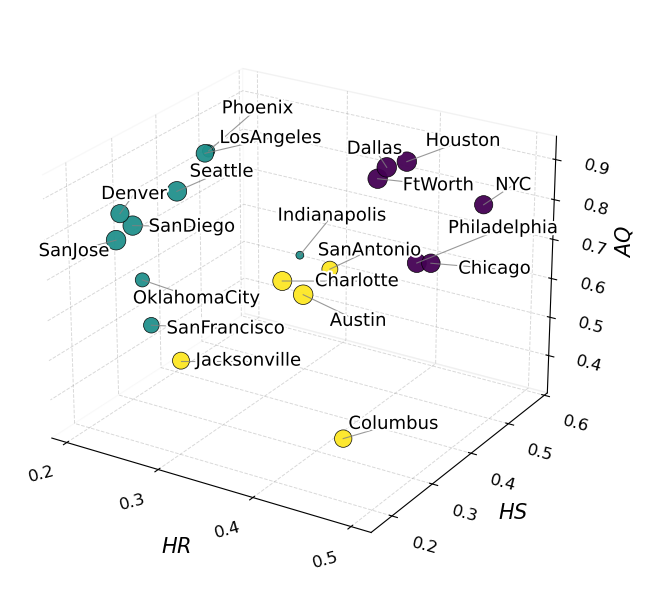

In [21]:
# Plot the optimized fuzzy C-Means classification

class_col = 'Fuzzy_Cluster_opt'
class_vals = df[class_col].values
classes = np.sort(np.unique(class_vals))
bg = 'white'
x = df['HydroRiskAvg'].values
y = df['HeatRiskAvg'].values
z = df['AQAvg'].values
names = df['City'].values

pad_x = 0.03 * (x.max() - x.min())
pad_y = 0.03 * (y.max() - y.min())
pad_z = 0.03 * (z.max() - z.min())

# --- SIZE BETWEEN ORIGINAL AND PREVIOUS (original was 8*0.9=7.2 x 6*0.9=5.4, last was 10x7.5) ---
fig = plt.figure(figsize=(9, 6.8))
fig.patch.set_facecolor(bg)
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor(bg)
ax.xaxis.pane.set_facecolor((1, 1, 1, 1))
ax.yaxis.pane.set_facecolor((1, 1, 1, 1))
ax.zaxis.pane.set_facecolor((1, 1, 1, 1))

scatter = ax.scatter(
    x, y, z,
    c=class_vals,
    s=df['Membership_opt']**2 * 200,
    alpha=0.95,
    depthshade=True,
    edgecolors='black',
    linewidths=0.5
)

ax.set_xlabel(f'$HR$', fontsize=15, labelpad=12)
ax.set_ylabel(f'$HS$', fontsize=15, labelpad=12)
ax.set_zlabel('')
fig.text(0.85, 0.56, f'$AQ$', rotation=90, va='center', ha='center', fontsize=15)

ax.tick_params(axis='both', which='major', labelsize=12)
ax.zaxis.set_tick_params(labelsize=12)

x_min, x_max = x.min() - pad_x, x.max() + pad_x
y_min, y_max = y.min() - pad_y, y.max() + pad_y
z_min, z_max = z.min() - pad_z, z.max() + pad_z

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_zlim(z_min, z_max)

ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# --- FIX DUPLICATE HR TICKS: explicitly set clean ticks within range ---
ax.set_xlim(x_min, 0.52)
x_ticks = np.array([0.2, 0.3, 0.4, 0.5])
ax.xaxis.set_major_locator(FixedLocator(x_ticks))

# HS at 0.1 intervals, clean within range
y_ticks = np.arange(np.ceil(y_min * 10) / 10, y_max + 0.001, 0.1)
y_ticks = np.round(y_ticks, 1)
ax.yaxis.set_major_locator(FixedLocator(y_ticks))

# Z ticks clean within range
z_ticks = np.arange(np.ceil(z_min * 10) / 10, z_max + 0.001, 0.1)
z_ticks = np.round(z_ticks, 1)
ax.zaxis.set_major_locator(FixedLocator(z_ticks))

ax.set_box_aspect((1.05, 1.0, 0.8))
ax.view_init(elev=24, azim=-58)
ax.grid(True)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['linestyle'] = '--'
    axis._axinfo["grid"]['linewidth'] = 0.7
    axis._axinfo["grid"]['color'] = (0.5, 0.5, 0.5, 0.3)

# --- TILTED TICK LABELS ---
for tick in ax.get_xticklabels():
    tick.set_rotation(15)
    tick.set_ha('right')

for tick in ax.get_yticklabels():
    tick.set_rotation(-15)
    tick.set_ha('left')

for tick in ax.get_zticklabels():
    tick.set_rotation(-15)
    tick.set_ha('left')

fig.canvas.draw()
x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
xy_pixels = ax.transData.transform(np.column_stack([x2, y2]))
xy_axes = ax.transAxes.inverted().transform(xy_pixels)

texts = []
for (xa, ya), label in zip(xy_axes, names):
    txt = ax.text2D(
        xa, ya, label,
        transform=ax.transAxes,
        fontsize=13,
        ha='left',
        va='bottom',
        color='black',
        path_effects=[pe.withStroke(linewidth=3, foreground='white')],
        zorder=10
    )
    texts.append(txt)

adjust_text(
    texts,
    ax=ax,
    expand=(1.15, 1.20),
    force_text=(0.6, 0.9),
    force_static=(0.4, 0.6),
    only_move={'text': 'xy'}
)

fig.canvas.draw()
for (xa, ya), txt in zip(xy_axes, texts):
    xt, yt = txt.get_position()
    line = Line2D(
        [xa, xt], [ya, yt],
        transform=ax.transAxes,
        color='gray',
        linewidth=0.8,
        alpha=0.8,
        zorder=9
    )
    ax.add_line(line)

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=classes.min(), vmax=classes.max())
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=cmap(norm(c)),
        markeredgecolor='none',
        markersize=10,
        label=f'Class {int(c)+1}'
    )
    for c in classes
]

plt.subplots_adjust(left=0.03, right=0.94, top=0.90, bottom=0.06)
#plt.savefig('city_clustering_fuzzy_opt_3d_5_12.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Date and time
now = datetime.datetime.now()
print(f"Date and time: {now}")

Date and time: 2026-06-04 11:14:43.080743
